#Desafio

Aluna: Maria Eduarda Alves

email: meas2@cesar.school

## Tópicos da atividade
Escolha uma série temporal - ok

Analise os dados (EDA c/ ACF, PACF, Estacionaridade, etc) - ok

Trate os dados - ok

Combine o uso de Model Rocket + Classificador ou Regressor a sua escolha - ok

Defina as métricas de avaliação - ok

Treine, teste e apresente os resultados - ok

Discuta sobre as diferenças do uso dessa abordagem vs. abordagens tradicionais, respondendo questões como (mas não limitada apenas a isso): seria necessário diferenciar? De que forma a diferenciação impactaria os resultados de abordagens tradicionais vs. a utilizada nessa atividade? Se faz necessário normalizar os dados?

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install yfinance pydataset pmdarima "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible

In [ ]:
# importando as bibliotecas
from pmdarima.arima import KPSSTest
import yfinance as yf
from pydataset import data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

**Sobre o Dataset**

A base dados consiste na coleta da temperatura mínima por 10 anos de 01/jan/1981 até 31/12/1990 coletado na Austrália.

O problema é de regressão pois estamos tentando prever o valor referente a temperatura.

In [ ]:
# lendo o dataframe
df_temp = pd.read_csv(r'/content/daily-minimum-temperatures-in-me.csv')

In [ ]:
df_temp.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


## EDA

In [ ]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        3650 non-null   object
 1   Daily minimum temperatures  3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB


Observações:

* A coluna Date é do tipo object e não data. Temos que converter o valor da coluna
* A coluna dos valores de temperatura é do tipo object mas deveria ser do tipo float

In [ ]:
df_temp[df_temp['Daily minimum temperatures'] == '?0.2']

,Date,Daily minimum temperatures
565,7/20/1982,?0.2


In [ ]:
# substituindo o valor incorreto
df_temp['Daily minimum temperatures'] = df_temp['Daily minimum temperatures'].apply(lambda x: x.replace('?',''))

In [ ]:
# convertendo valores do tipo data e float
df_temp['Date'] = df_temp['Date'].astype('datetime64[ns]')
df_temp['Daily minimum temperatures'] = df_temp['Daily minimum temperatures'].astype('float32')

In [ ]:
# verificando valores duplicados
for c in df_temp.columns:
  print(f"Coluna - {c} - qtd de valores duplicados - {df_temp[c].duplicated().sum()}")

Coluna - Date - qtd de valores duplicados - 0
Coluna - Daily minimum temperatures - qtd de valores duplicados - 3421


Observação:

a coluna de valor da temperatura se repete bastante, no caso de 3650 valores 3420 se repete representando 93,69% dos dados

In [ ]:
df_temp.describe()

,Date,Daily minimum temperatures
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177753
min,1981-01-01 00:00:00,0.000000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.299999
std,NaN,4.071843


Observações:

O valor mínimo de temperatura é 0 e o máximo é de 26,3. Não foi informado qual é a unidade de medida mas pesquisando deve ser o graus Celsius.

Visualizando a série temporal

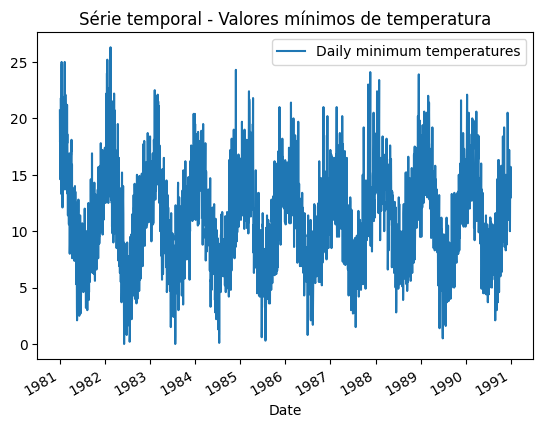

In [ ]:
df_temp.plot(x='Date', y='Daily minimum temperatures')
plt.title("Série temporal - Valores mínimos de temperatura")
plt.show()

In [ ]:
# verificando as trends
def create_trend(df: pd.DataFrame, trend_size: int | float):
  return df.rolling(trend_size).mean().values

In [ ]:
df_temp["trend_30d"] = create_trend(df_temp['Daily minimum temperatures'], 30)
df_temp["trend_180d"] = create_trend(df_temp['Daily minimum temperatures'], 180)
df_temp["trend_365d"] = create_trend(df_temp['Daily minimum temperatures'], 365)

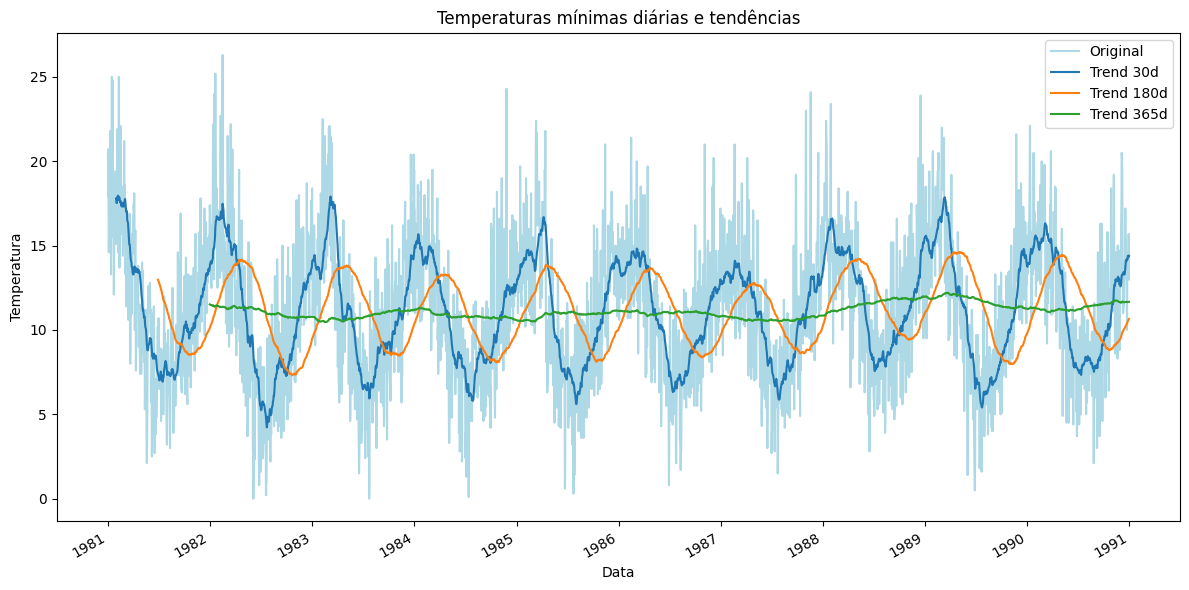

In [ ]:
plt.figure(figsize=(12, 6))
ax = plt.gca()  # Pega o eixo atual

# Plotando todos no mesmo eixo
df_temp.plot(x='Date', y='Daily minimum temperatures', ax=ax, label='Original',color='lightblue')
df_temp.plot(x='Date', y='trend_30d', ax=ax, label='Trend 30d')
df_temp.plot(x='Date', y='trend_180d', ax=ax, label='Trend 180d')
df_temp.plot(x='Date', y='trend_365d', ax=ax, label='Trend 365d')

# Ajustes visuais
ax.set_title('Temperaturas mínimas diárias e tendências')
ax.set_xlabel('Data')
ax.set_ylabel('Temperatura')
plt.legend()
plt.tight_layout()
plt.show()

Observação:

Aparentemente a visualização que se refere a trend dos 30 dias consegue se enquadrar melhor com a série original

## Verificando o ACF e PCF

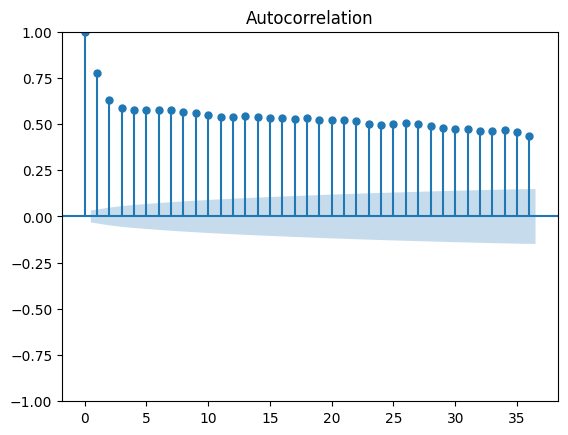

In [ ]:
plot_acf(df_temp['Daily minimum temperatures'])
plt.show()

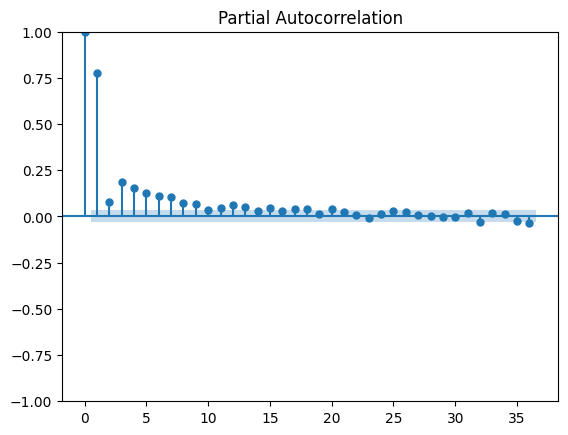

In [ ]:
plot_pacf(df_temp['Daily minimum temperatures'])
plt.show()

## Verificando a estacionariedade da série

In [ ]:
# testando se a série é estacionária ou se devemos diferenciar
kpss_ = KPSSTest()
kpss_df_air = kpss(df_temp['Daily minimum temperatures'])
print(kpss_df_air)
print(f"KPSS Test [e estacionaria?]: {kpss_df_air[1] >= 0.05}")
print(kpss_.should_diff(df_temp['Daily minimum temperatures']))

(0.05570612670427435, 0.1, 36, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
KPSS Test [e estacionaria?]: True
(0.1, False)


De acordo com o KPSS teste a série é estacionária então não se torna necessário aplicar diferenciação nela.

## Aplicando os modelos

Combine o uso de Model Rocket + Classificador ou Regressor a sua escolha


nas séries temporais não podemos perder a ordem cronológica dos dados. Então separamos uma porcentagem para treino e outra para teste, sendo 80% para treino e 20% para teste. O treino fica com os dados mais antigos e o teste fica com os dados mais recentes.

### Model rocket (tsai)

In [ ]:
!pip install sktime
!pip install tsai

In [ ]:
from tsai.all import *
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

**Model Rocket**

MiniRocketFeatures é um transformador do pacote sktime que serve para extrair características (features) de séries temporais usando uma técnica chamada ROCKET — Random Convolutional Kernel Transform.

MiniRocketFeatures (c_in, seq_len, num_features=10000,
                     max_dilations_per_kernel=32, random_state=None)

* c_in = numero de canais de entrada
* seq_len = Comprimento da série temporal
* num_features = Número de features a extrair (número de kernels)
* max_dilations_per_kernel = Controle da dilatação temporal por kernel
* random_state = Controle de aleatoriedade

**MiniRocketHead**

Em tsai, MiniRocketHead é um modelo projetado para ser usado junto com a transformação MiniRocket. Ele espera como entrada os dados crús (no formato (n_samples, n_channels, seq_len)).

In [ ]:
# preciso definir uma janela de tempo que vou agrupar os meus dados. Como a trend com 30 dias foi boa então vou considerar a janela de 30 dias
window_size = 30

X_list, y_list = [], []
temps = df_temp['Daily minimum temperatures'].values

for i in range(len(temps) - window_size):
    X_list.append(temps[i:i+window_size])      # janela de 30 dias
    y_list.append(temps[i+window_size])        # próximo valor (alvo)

X = np.array(X_list)  # shape: (n_instâncias, window_size)
y = np.array(y_list)

In [ ]:
X.shape

(3620, 30)

In [ ]:
X.ndim

2

In [ ]:
y.shape

(3620,)

In [ ]:
y.ndim

1

In [ ]:
# preciso adicionar uma dimensão no canal para adaptar meu valor para o minirocket
X = X[:, np.newaxis, :]

In [ ]:
X.shape

(3620, 1, 30)

In [ ]:
# Inicializa o extrator
mrf = MiniRocketFeatures(X.shape[1], X.shape[2])
mrf.fit(X)

In [ ]:
X_rocket = get_minirocket_features(X, mrf, to_np=True)
X_rocket.shape

(3620, 9996, 1)

In [ ]:
# Gerando os índices para criar o split de treino e validação
idxs = np.arange(len(X_rocket))
train_idx, valid_idx = train_test_split(idxs, test_size=0.3, random_state=42)
splits = (list(train_idx), list(valid_idx))

In [ ]:
tfms = [None, [TSRegression()]]
temp_dls = get_ts_dls(X_rocket, y, splits=splits, tfms=tfms)

# Modelo e learner
temp_model = build_ts_model(MiniRocketHead, dls=temp_dls)
temp_learn = Learner(temp_dls, temp_model, metrics=rmse, cbs=ShowGraph())

In [ ]:
temp_model.head

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): BatchNorm1d(9996, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Linear(in_features=9996, out_features=1, bias=True)
)

SuggestedLRs(valley=0.0014454397605732083)

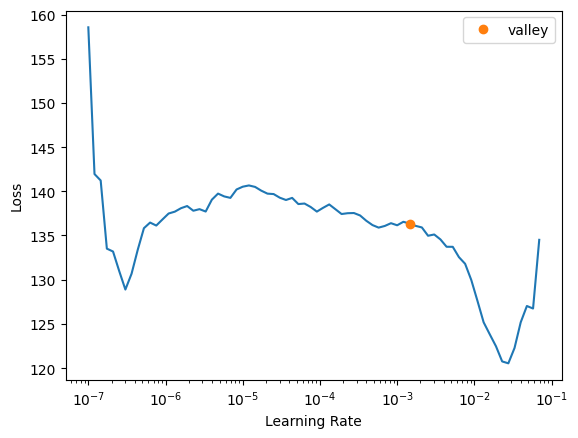

In [ ]:
temp_learn = Learner(temp_dls, temp_model, metrics=rmse, cbs=ShowGraph())
temp_learn.lr_find()

Valor sugerido de 1e-3

epoch,train_loss,valid_loss,_rmse,time
0,132.693436,135.034378,11.620429,00:00
1,129.035828,126.373405,11.241592,00:00
2,112.867386,70.009201,8.367150,00:00
3,62.184307,12.432980,3.526043,00:00
4,31.011997,9.488907,3.080407,00:00
5,16.828045,8.484600,2.912833,00:00
6,10.322237,7.976650,2.824296,00:00
7,7.054777,8.334335,2.886925,00:00
8,5.901369,8.291469,2.879491,00:00
9,5.047644,9.464989,3.076522,00:00


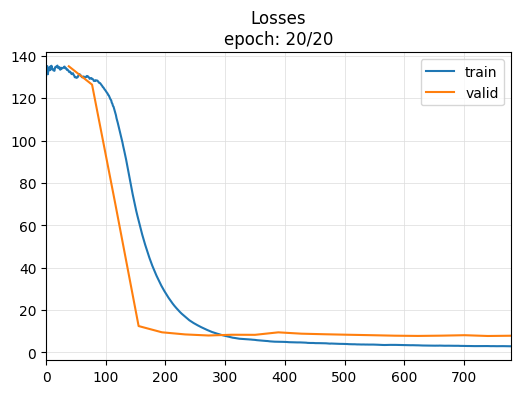

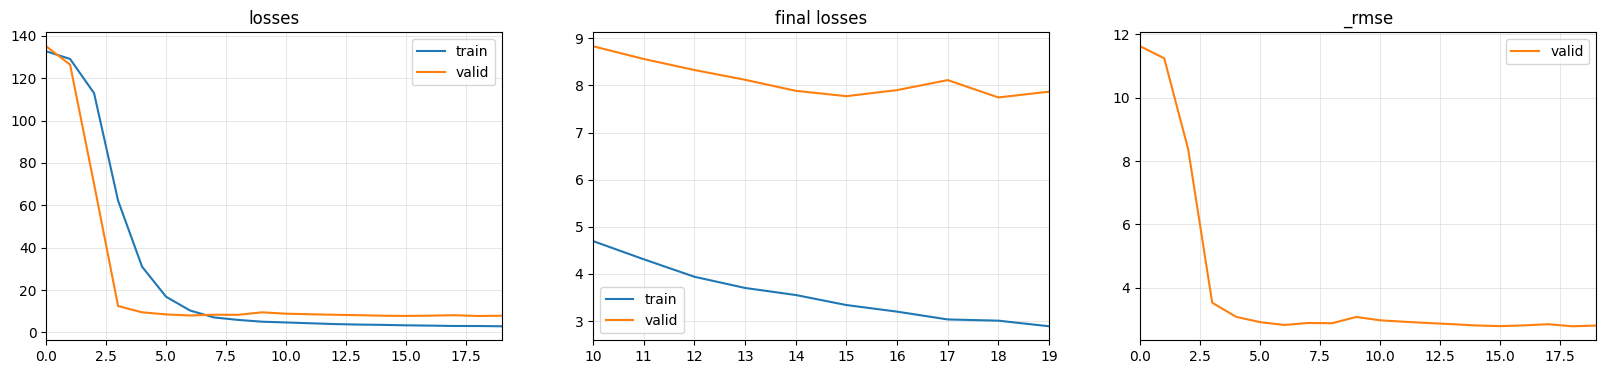

In [ ]:
temp_learn.fit_one_cycle(20, 1e-3)

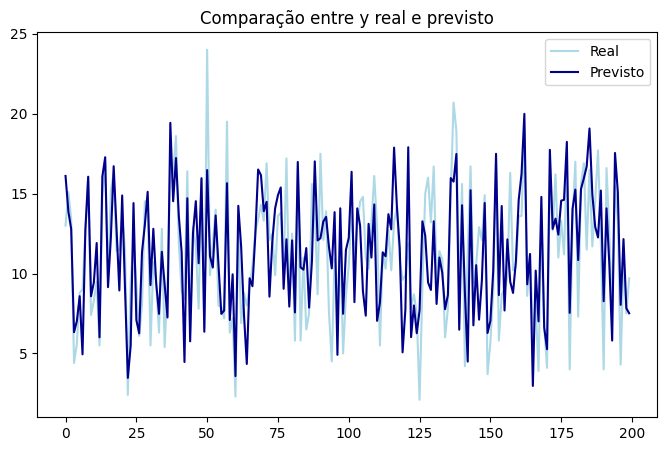

In [ ]:
# previsões e target
preds, targs = temp_learn.get_preds()

plt.figure(figsize=(8,5))
plt.plot(targs[:200], label='Real',color='lightblue')
plt.plot(preds[:200], label='Previsto',color='darkblue')
plt.legend()
plt.title('Comparação entre y real e previsto')
plt.show()

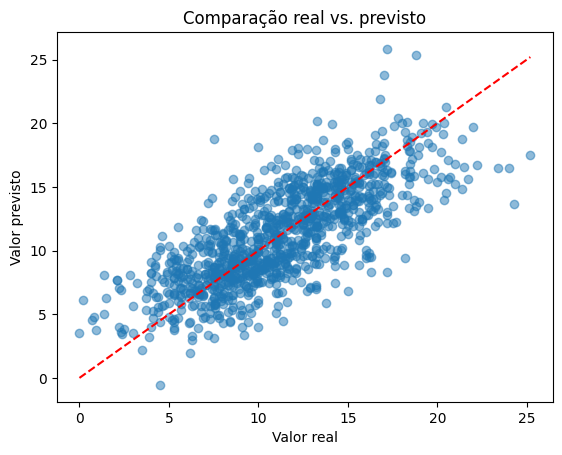

In [ ]:
plt.scatter(targs, preds, alpha=0.5)
plt.xlabel('Valor real')
plt.ylabel('Valor previsto')
plt.title('Comparação real vs. previsto')
plt.plot([targs.min(), targs.max()], [targs.min(), targs.max()], 'r--')
plt.show()

**MLP**

In [ ]:
mlp_learn = ts_learner(temp_dls, MLP, metrics=[mae, rmse], cbs=ShowGraph())

SuggestedLRs(valley=0.005248074419796467)

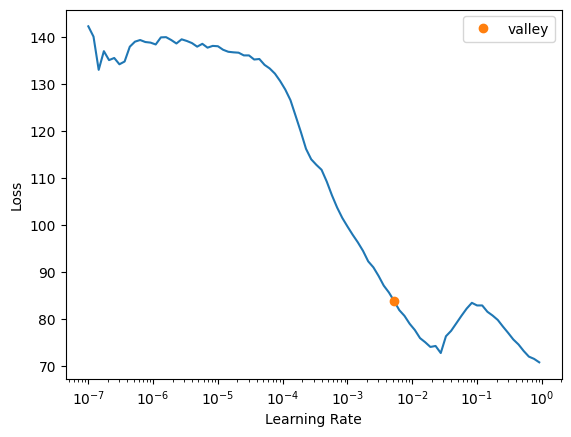

In [ ]:
mlp_learn.lr_find()

epoch,train_loss,valid_loss,mae,_rmse,time
0,59.006634,17.539577,3.402244,4.188028,00:03
1,30.880219,15.861172,3.218686,3.982608,00:04
2,21.624470,14.657745,3.017027,3.828543,00:04
3,15.678525,14.357200,3.028964,3.789089,00:04
4,12.277859,7.719624,2.162461,2.778421,00:04
5,10.721234,8.426582,2.309353,2.902858,00:04
6,9.709739,7.257626,2.093392,2.693998,00:04
7,9.175713,10.198321,2.493302,3.193481,00:04
8,9.020248,7.739157,2.153179,2.781934,00:04
9,8.184440,7.304982,2.092664,2.702773,00:04


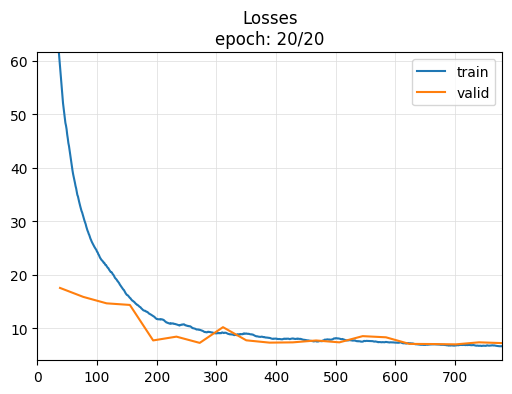

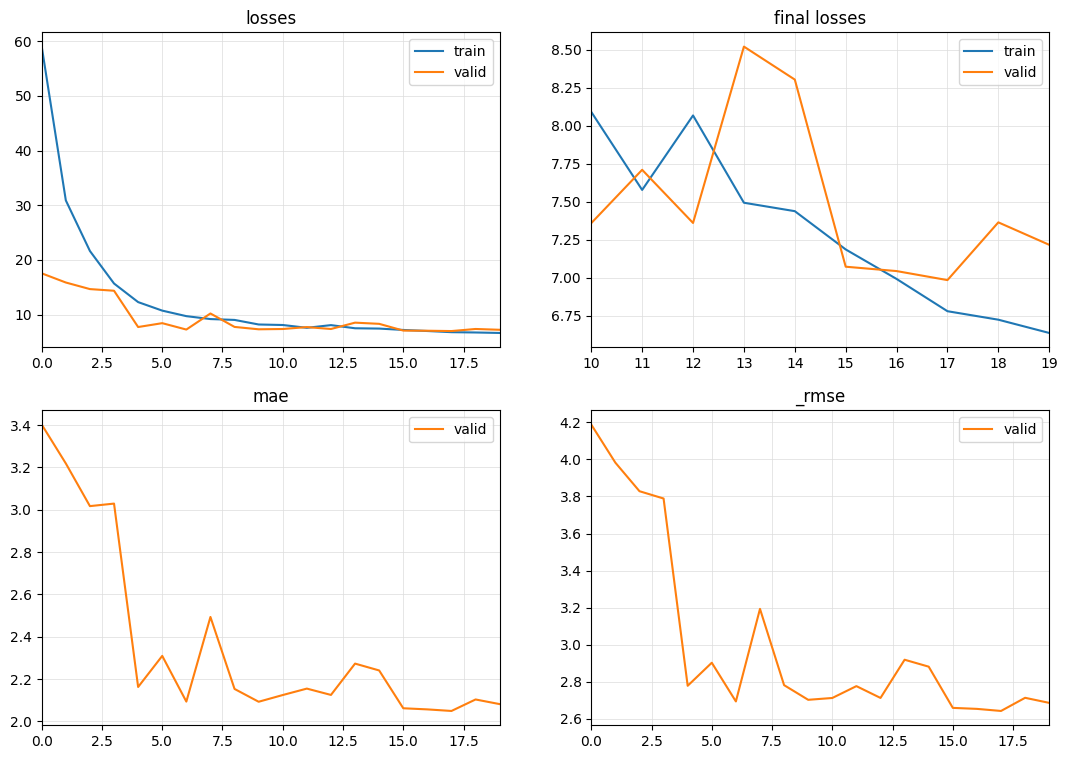

In [ ]:
mlp_learn.fit_one_cycle(20,1e-3)

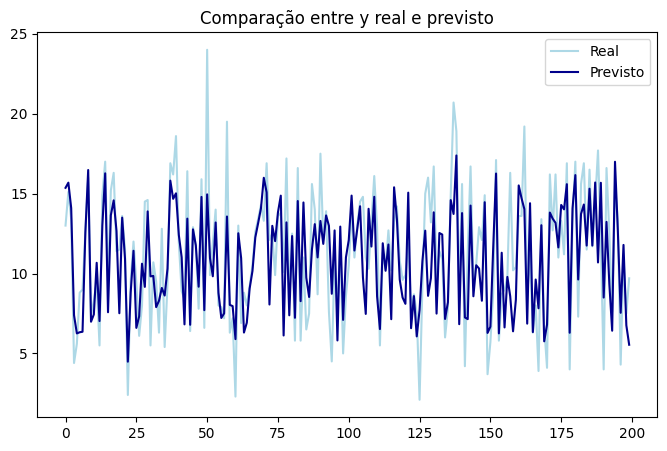

In [ ]:
# previsões e target
preds, targs = mlp_learn.get_preds()

plt.figure(figsize=(8,5))
plt.plot(targs[:200], label='Real',color='lightblue')
plt.plot(preds[:200], label='Previsto',color='darkblue')
plt.legend()
plt.title('Comparação entre y real e previsto')
plt.show()

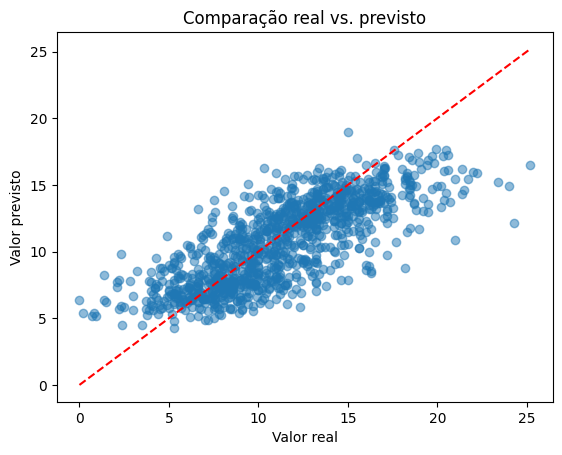

In [ ]:
plt.scatter(targs, preds, alpha=0.5)
plt.xlabel('Valor real')
plt.ylabel('Valor previsto')
plt.title('Comparação real vs. previsto')
plt.plot([targs.min(), targs.max()], [targs.min(), targs.max()], 'r--')
plt.show()

## Definição das métricas de avaliação

Para regressão foi definido as métricas de rmse e mae

In [ ]:
#temp_learn -> rmse
#temp_learn -> mae e rmse

In [ ]:
temp_learn.validate() # [val_loss, rmse]

not enough values to plot a chart


(#2) [7.868473529815674,2.805079936981201]

In [ ]:
mlp_learn.validate()  # [val_loss, rmse, mae]

not enough values to plot a chart


(#3) [7.215733051300049,2.081505298614502,2.686211585998535]

* Comparando as métricas é possível ver que o erro é menor para o MLP do que para o modelo treinado com o MiniRocketHead.
* É possível visualizar no gráfico de resíduos que os valores estão menos dispersos sobre o modelo MLP do que o MiniRocketHead também.